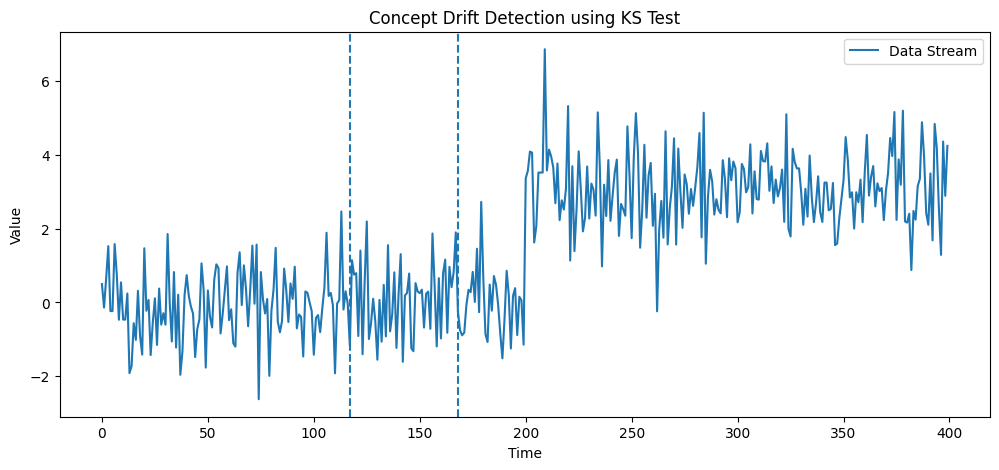

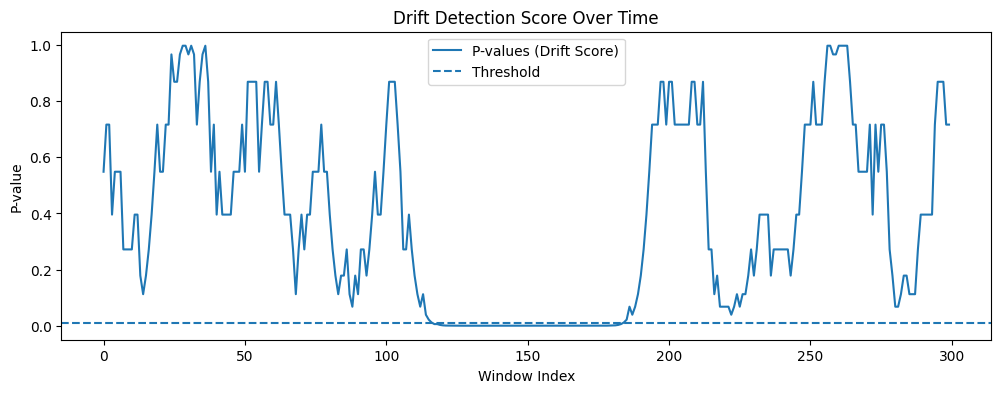

Detected drift points: [117, 168]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp  # Kolmogorov-Smirnov test

# ============================================
# 1. SIMULATE DATA STREAM WITH DRIFT
# ============================================

np.random.seed(42)

# Before drift
data_part1 = np.random.normal(loc=0, scale=1, size=200)

# After drift (mean shift)
data_part2 = np.random.normal(loc=3, scale=1, size=200)

# Combine stream
data_stream = np.concatenate([data_part1, data_part2])

# ============================================
# 2. DRIFT DETECTION USING SLIDING WINDOW + KS TEST
# ============================================

window_size = 50
p_values = []
drift_points = []

alpha = 0.01  # significance level (strict)

for i in range(len(data_stream) - 2 * window_size):
    window1 = data_stream[i:i + window_size]
    window2 = data_stream[i + window_size:i + 2 * window_size]

    # KS statistical test
    stat, p_value = ks_2samp(window1, window2)
    p_values.append(p_value)

    # Detect drift when distributions differ significantly
    if p_value < alpha:
        drift_points.append(i)

# ============================================
# 3. POST-PROCESS DRIFT POINTS (REDUCE NOISE)
# ============================================

# Keep only major drift region (avoid too many lines)
filtered_drift = []

for i in drift_points:
    if not filtered_drift or i - filtered_drift[-1] > window_size:
        filtered_drift.append(i)

# ============================================
# 4. VISUALIZATION
# ============================================

plt.figure(figsize=(12, 5))

# Plot data
plt.plot(data_stream, label="Data Stream")

# Mark drift regions
for point in filtered_drift:
    plt.axvline(x=point, linestyle='--')

plt.title("Concept Drift Detection using KS Test")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

# ============================================
# 5. DRIFT SCORE VISUALIZATION
# ============================================

plt.figure(figsize=(12, 4))
plt.plot(p_values, label="P-values (Drift Score)")
plt.axhline(y=alpha, linestyle='--', label="Threshold")

plt.title("Drift Detection Score Over Time")
plt.xlabel("Window Index")
plt.ylabel("P-value")
plt.legend()
plt.show()

# ============================================
# 6. OUTPUT
# ============================================

print("Detected drift points:", filtered_drift)